# 2D Linear Elasticity

Continuous linear elasticity describes the small deformations of an elastic body under applied loads. Let $\Omega \subset \mathbb{R}^d$ be the reference configuration of the body, and let $u : \Omega \to \mathbb{R}^d$ denote the displacement field. Under the assumptions of small strains and linear material response, the infinitesimal strain tensor is defined as
$$\boldsymbol{E}(u) = \tfrac{1}{2}\left(\nabla u + \nabla u^\top\right).$$

The corresponding Cauchy stress tensor for isotropic material is 
$$\boldsymbol{S}(u) = 2\mu\, \boldsymbol{E}(u) + \lambda \, \mathrm{tr}\!\left(\boldsymbol{E}(u)\right)\, I,$$
where $\lambda$ and $\mu$ are the Lamé parameters, $\mathrm{tr}(\cdot)$ denotes the trace operator, and $I$ is the identity tensor.

The strong form of the linear elasticity problem consists in finding $u$ such that
$$-\text{div}(\boldsymbol{S}(u)) = f \quad \text{in } \Omega,$$
together with appropriate Dirichlet (prescribed displacement) and Neumann (prescribed traction) boundary conditions.

We will also consider the variational (weak) formulation: in the case of Dirichlet BC, find $u$ in a suitable function space such that
$$u = \text{argmin}_v \int_\Omega \boldsymbol{E}(v) \cdot \boldsymbol{S}(v)\,\mathrm{d}x - \int_\Omega v \cdot f\,\mathrm{d}x,$$
where $v$ denotes admissible test functions. This formulation can be interpreted as the first-order optimality condition of the total elastic energy and forms the basis of most numerical methods.

In this notebook, we will solve the linear elasticity problem using **Discrete Exterior Calculus (DEC)**. By expressing the governing equations and the variational formulation in terms of discrete differential forms and Hodge star operators, DEC provides a geometrically consistent and structure-preserving framework for discretizing linear elasticity on simplicial complexes.

## Imports and config setup

In [1]:
import numpy as np
from dctkit.mesh import util
from dctkit.math.opt import optctrl
from dctkit.physics.elasticity import LinearElasticity
import dctkit as dt
import pygmsh
import jax.numpy as jnp
from functools import partial
import matplotlib.pyplot as plt
import dctkit.dec.cochain as C
from dctkit.dec.flat import *

In [2]:
dt.config()

## Simplicial complex, test problem and boundary conditions

First of all we create the 2-simplicial complex, which in this case is the discretization of the unit square $[0,1]^2$. We then consider the deformation scenario called **uniaxial tension**, in which both the stress and strain tensors are constants and are given by
$$\boldsymbol{S}_{pt} =
\begin{bmatrix}
s & 0 \\
0 & 0
\end{bmatrix}, \quad \boldsymbol{E}_{pt} =
\begin{bmatrix}
\varepsilon & 0 \\
0 & \ell
\end{bmatrix},$$
where $s = 2\mu\varepsilon + \lambda(\varepsilon + \ell)$, and $\ell = - \lambda\varepsilon/(2\mu + \lambda)$.

In [3]:
lc = 0.2
L = 1.
with pygmsh.geo.Geometry() as geom:
    p = geom.add_polygon([[0., 0.], [L, 0.], [L, L], [0., L]], mesh_size=lc)
    # create a default physical group for the boundary lines
    geom.add_physical(p.lines, label="boundary")
    geom.add_physical(p.lines[1], label="right")
    geom.add_physical(p.lines[3], label="left")
    mesh = geom.generate_mesh()

S = util.build_complex_from_mesh(mesh)
S.get_hodge_star()
S.get_flat_DPD_weights()
S.get_flat_DPP_weights()

In [4]:
ref_node_coords = S.node_coords

bnd_edges_idx = S.boundary_simplices[S.dim-1]
left_bnd_nodes_idx = util.get_nodes_for_physical_group(mesh, 1, "left")
right_bnd_nodes_idx = util.get_nodes_for_physical_group(mesh, 1, "right")
left_bnd_edges_idx = util.get_edges_for_physical_group(S, mesh, "left")
right_bnd_edges_idx = util.get_edges_for_physical_group(S, mesh, "right")

bot_left_corn_idx = left_bnd_nodes_idx.index(0)
bottom_left_corner = left_bnd_nodes_idx[bot_left_corn_idx]

In [5]:
mu_ = 1.
lambda_ = 10.
true_strain_xx = 0.5
true_strain_yy = -(lambda_/(2*mu_+lambda_))*true_strain_xx
true_curr_node_coords = S.node_coords.copy()
true_curr_node_coords[:, 0] *= 1 + true_strain_xx
true_curr_node_coords[:, 1] *= 1 + true_strain_yy
left_bnd_pos_components = [0]
right_bnd_pos_components = [0]

In [6]:
left_bnd_nodes_pos = ref_node_coords[left_bnd_nodes_idx,
                                         :][:, left_bnd_pos_components]
right_bnd_nodes_pos = true_curr_node_coords[right_bnd_nodes_idx,
                                            :][:, right_bnd_pos_components]
bottom_left_corner_pos = ref_node_coords[bottom_left_corner, :]

In [7]:
boundary_values = {"0": (left_bnd_nodes_idx + right_bnd_nodes_idx,
                         np.vstack((left_bnd_nodes_pos,
                                    right_bnd_nodes_pos)).flatten()),
                   ":": (bottom_left_corner, bottom_left_corner_pos)}

idx_free_edges = list(set(bnd_edges_idx) -
                      set(right_bnd_edges_idx) - set(left_bnd_edges_idx))
left_right_edges_idx = left_bnd_edges_idx+right_bnd_edges_idx
bnd_tractions_free_values = np.zeros((len(idx_free_edges), 2), dtype=dt.float_dtype)
bnd_tractions_left_right_values = np.zeros(
    (len(left_right_edges_idx)), dtype=dt.float_dtype)

boundary_tractions = {':': (idx_free_edges, bnd_tractions_free_values),
                      '1': (left_right_edges_idx, bnd_tractions_left_right_values)}

gamma = 100000.

## Utils

Now we define the scripts needed to compute the strain and stress tensors. They are computed as in the continous formulation starting from the deformation gradient, which is computed using the class method `get_deformation_gradient`

In [8]:
def get_infinitesimal_strain(node_coords):
        """Compute the discrete strain tensor given the current node coordinates.

        Args:
            node_coords: current node coordinates.

        Returns:
            the discrete infinitesimal strain tensor.

        """
        # compute the deformation gradient
        num_faces = S.S[2].shape[0]
        F = S.get_deformation_gradient(node_coords)
        # epsilon = 1/2(F + F^T) - I
        epsilon = 1/2 * (F + jnp.transpose(F, axes=(0, 2, 1))) - \
            jnp.stack([jnp.identity(2)]*num_faces)
        return epsilon

def get_stress(strain):
    """Compute the discrete stress tensor from strains using the consistutive
    equation for isotropic linear elastic materials.

    Args:
        strain: discrete strain tensor.

    Returns:
        the discrete stress tensor.

    """
    num_faces = S.S[2].shape[0]
    tr_strain = jnp.trace(strain, axis1=1, axis2=2)
    # get the stress via the consistutive equation for isotropic linear
    # elastic materials
    stress = 2.*mu_*strain + lambda_*tr_strain[:, None, None] * \
        jnp.stack([jnp.identity(2)]*num_faces)
    return stress

def get_penalty_displacement_bc(node_coords, boundary_values, gamma):
        """Set displacement boundary conditions as a quadratic penalty term.

        Args:
            node_coords: node coordinates of the current configuration.
            boundary_values: a dictionary of tuples. Each key represent the type of
                coordinate to manipulate (x,y, or both), while each tuple consists of
                two np.arrays in which the first encodes the indices of boundary
                values, while the last encodes the boundary values themselves.
            gamma: penalty factor.

        Return:
            the penalty term.
        """
        penalty = 0.
        for key in boundary_values:
            idx, values = boundary_values[key]
            if key == ":":
                penalty += jnp.sum((node_coords[idx, :] - values)**2)
            else:
                penalty += jnp.sum((node_coords[idx, int(key)] - values)**2)
        return gamma*penalty

def set_boundary_tractions(forces,boundary_tractions):
        """Set the boundary tractions on primal edges.

        Args:
            forces: vector-valued primal 1-cochain containing forces acting on primal
                edges.
            boundary_tractions: a dictionary of tuples. Each key represent the type
                of coordinate to manipulate (x,y, or both), while each tuple consists
                of two jax arrays, in which the first encordes the indices where we
                want to impose the boundary tractions, while the last encodes the
                boundary traction values themselves.

        Returns:
            the updated force 1-cochain.

        """
        for key in boundary_tractions:
            idx, values = boundary_tractions[key]
            if key == ":":
                forces.coeffs = forces.coeffs.at[idx, :].set(values)
            else:
                forces.coeffs = forces.coeffs.at[idx, int(key)].set(values)
        return forces

## Variational Formulation

In the DEC framework, $\boldsymbol{S}$ and $\boldsymbol{E}$ are defined as dual tensor-valued 0-cochains, while $u$ and $f$ are primal vector-valued 0-cochains. The variational DEC-formulation can be written as
$$\mathcal{E}_{LE} := \frac{1}{2} \langle \boldsymbol{S}, \boldsymbol{E} \rangle - \langle u, f \rangle.$$

In [9]:
def elasticity_energy(node_coords, f):
        """Compute the elasticity energy of isotropic linear elastic materials
        in 2D with no body force using DEC framework.

        Args:
            node_coords: primal vector valued 0-cochain of node coordinates
                of the current configuration.
            f: primal vector-valued 0-cochain of sources.

        Returns:
            the energy.
        """
        strain = get_infinitesimal_strain(node_coords=node_coords.coeffs)
        stress = get_stress(strain=strain)
        strain_cochain = C.CochainD0(S, strain)
        stress_cochain = C.CochainD0(S, stress)
        ref_node_coords = C.CochainP0(S, S.node_coords)
        displacement = C.sub(node_coords, ref_node_coords)
        elastic_energy = 0.5 * \
            C.inner(strain_cochain, stress_cochain) - \
            C.inner(displacement, f)
        return elastic_energy

In [10]:
def obj_linear_elasticity_energy(node_coords, f, gamma, boundary_values):
        """
        Objective function of the optimization problem associated to linear elasticity
        (energy formulation) with Dirichlet boundary conditions on a portion of the
        boundary.

        Args:
            node_coords: 1-dimensional array obtained after flattening the matrix with
                node coordinates arranged row-wise.
            f: matrix of external sources (constant term of the system).
            gamma: penalty factor.
            boundary_values: a dictionary of tuples. Each key represent the type
                of coordinate to manipulate (x,y, or both), while each tuple consists
                of two np.arrays in which the first encodes the indices of boundary
                values, while the last encodes the boundary values themselves.

        Returns:
            the value of the objective function at node_coords.
        """
        node_coords_reshaped = node_coords.reshape(S.node_coords.shape)
        node_coords_coch = C.CochainP0(complex=S, coeffs=node_coords_reshaped)
        f_coch = C.CochainP0(complex=S, coeffs=f)
        elastic_energy = elasticity_energy(node_coords_coch, f_coch)
        penalty = get_penalty_displacement_bc(node_coords=node_coords_reshaped,
                                              boundary_values=boundary_values,
                                              gamma=gamma)
        energy = elastic_energy + penalty
        return energy

In [11]:
num_faces = S.S[2].shape[0]
embedded_dim = S.space_dim
f = np.zeros((S.num_nodes, embedded_dim))
obj = obj_linear_elasticity_energy
obj_args = {'f': f, 'gamma': gamma, 'boundary_values': boundary_values}
x0 = S.node_coords.flatten()

In [12]:
prb = optctrl.OptimizationProblem(dim=len(x0), state_dim=len(x0), objfun=obj)
prb.set_obj_args(obj_args)
sol = prb.solve(x0=x0, ftol_abs=1e-12, ftol_rel=1e-12, maxeval=100000)

In [13]:
curr_node_coords = sol.reshape(S.node_coords.shape)

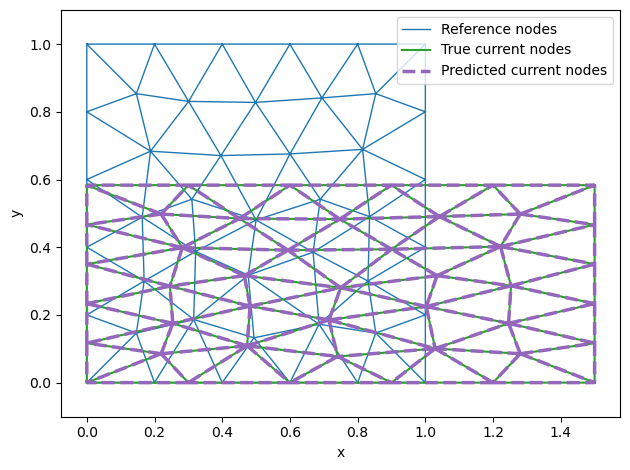

In [14]:
# Reference configuration
plt.triplot(
    ref_node_coords[:, 0],
    ref_node_coords[:, 1],
    triangles=S.S[2],
    linewidth=1.0,
    label="Reference nodes"
)

# True current configuration
plt.triplot(
    true_curr_node_coords[:, 0],
    true_curr_node_coords[:, 1],
    triangles=S.S[2],
    linewidth=1.5,
    label="True current nodes"
)

# Predicted current configuration (highlighted)
plt.triplot(
    curr_node_coords[:, 0],
    curr_node_coords[:, 1],
    triangles=S.S[2],
    linewidth=2.5,
    label="Predicted current nodes",
    linestyle="--",
)

# Axis labels and formatting
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.tight_layout()

plt.show()

## Non-variational formulation

In this case, the strong form equation assumes the following form in the DEC framework:
$$d(\star \flat \boldsymbol{S}) + f = 0,$$
where $\flat$ is the DPD flat operator firstly introduced in [Hirani 2003](https://www.cs.jhu.edu/~misha/Fall09/Hirani03.pdf).

In [15]:
def force_balance_residual_primal(node_coords, f, boundary_tractions):
        """Compute the residual of the discrete balance equation in the case
          of isotropic linear elastic materials in 2D using DEC framework.

        Args:
            node_coords: primal vector valued 0-cochain of node coordinates of the
                current configuration.
            f: primal vector-valued 2-cochain of sources.
            boundary_tractions: a dictionary of tuples. Each key represent the type
                of coordinate to manipulate (x,y, or both), while each tuple consists
                of two jax arrays, in which the first encordes the indices where we
                want to impose the boundary tractions, while the last encodes the
                boundary traction values themselves.

        Returns:
            the residual vector-valued cochain.

        """
        strain = get_infinitesimal_strain(node_coords=node_coords.coeffs)
        stress = get_stress(strain=strain)
        stress_tensor = C.CochainD0T(complex=S, coeffs=stress)
        stress_integrated = flat_DPD(stress_tensor)
        forces = C.star(stress_integrated)
        # set tractions on given sub-portions of the boundary
        forces_bnd_update = set_boundary_tractions(forces, boundary_tractions)
        residual = C.add(C.coboundary(forces_bnd_update), f)
        return residual




def obj_linear_elasticity_primal(node_coords, f, gamma, boundary_values, boundary_tractions):
        """
        Objective function of the optimization problem associated to linear
        elasticity balance equation with Dirichlet boundary conditions on a portion
        of the boundary.

        Args:
            node_coords: 1-dimensional array obtained after flattening the matrix with
                node coordinates arranged row-wise.
            f: matrix of external sources (constant term of the system).
            gamma: penalty factor.
            boundary_values: a dictionary of tuples. Each key represent the type of
                coordinate to manipulate (x,y, or both), while each tuple consists of
                two np.arrays in which the first encodes the indices of boundary
                values, while the last encodes the boundary values themselves.
            boundary_tractions: a dictionary of tuples. Each key represent the type
                of coordinate to manipulate (x,y, or both), while each tuple consists
                of two jax arrays, in which the first encordes the indices where we want
                to impose the boundary tractions, while the last encodes the boundary
                traction values themselves. It is None when we perform the force balance
                on dual cells.

        Returns:
            the value of the objective function at node_coords.

        """
        node_coords_reshaped = node_coords.reshape(S.node_coords.shape)
        node_coords_coch = C.CochainP0(complex=S, coeffs=node_coords_reshaped)
        f_coch = C.CochainP2(complex=S, coeffs=f)
        residual = force_balance_residual_primal(
            node_coords_coch, f_coch, boundary_tractions).coeffs
        penalty = get_penalty_displacement_bc(node_coords=node_coords_reshaped,
                                              boundary_values=boundary_values,
                                              gamma=gamma)
        energy = jnp.sum(residual**2) + penalty
        return energy

In [16]:
num_faces = S.S[2].shape[0]
embedded_dim = S.space_dim
f = np.zeros((num_faces, (embedded_dim-1)))
obj = obj_linear_elasticity_primal
obj_args = {'f': f,
            'gamma': gamma,
            'boundary_values': boundary_values,
            'boundary_tractions': boundary_tractions}
x0 = S.node_coords.flatten()

In [17]:
prb = optctrl.OptimizationProblem(dim=len(x0), state_dim=len(x0), objfun=obj)
prb.set_obj_args(obj_args)
sol = prb.solve(x0=x0, ftol_abs=1e-12, ftol_rel=1e-12, maxeval=100000)
curr_node_coords = sol.reshape(S.node_coords.shape)

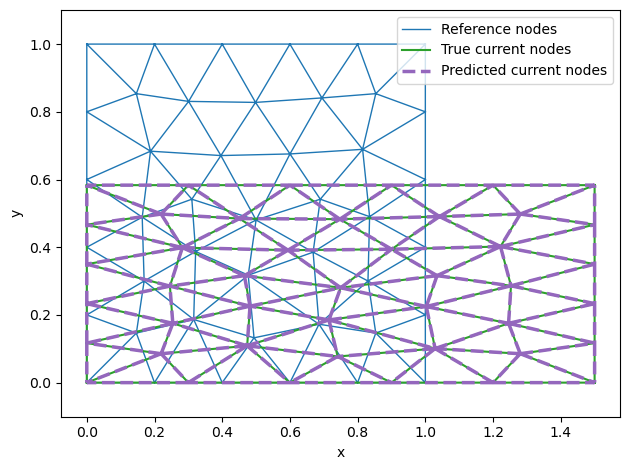

In [18]:
# Reference configuration
plt.triplot(
    ref_node_coords[:, 0],
    ref_node_coords[:, 1],
    triangles=S.S[2],
    linewidth=1.0,
    label="Reference nodes"
)

# True current configuration
plt.triplot(
    true_curr_node_coords[:, 0],
    true_curr_node_coords[:, 1],
    triangles=S.S[2],
    linewidth=1.5,
    label="True current nodes"
)

# Predicted current configuration (highlighted)
plt.triplot(
    curr_node_coords[:, 0],
    curr_node_coords[:, 1],
    triangles=S.S[2],
    linewidth=2.5,
    label="Predicted current nodes",
    linestyle="--",
)

# Axis labels and formatting
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.tight_layout()

plt.show()